# Comprehensive Statistical Results Report

This notebook contains the complete visual and statistical breakdown of all significant findings from our analysis of the restaurant transactions dataset. 

For every statistically significant factor (p < 0.05) found during the exploratory phase, this notebook provides:
1. **The Raw Statistical Output:** The ANOVA table or Welch's t-test summary.
2. **The Visuals:** Corresponding residual diagnostics or bar/box plots.
3. **The Analysis:** An automatically generated Markdown report breaking down the observation and providing actionable managerial insight.

*Note: Tip-related ANOVA hypotheses are deferred for medians due to audit flags for extreme values.*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
import warnings
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('Restaurant_Cleaned.csv')

# Ensure numeric types
for c in ['Amount','Tip','Partysize']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

def group_partysize(s):
    if s <= 2: return 'Small [1-2]'
    elif s <= 4: return 'Medium [3-4]'
    else: return 'Large [5+]'
df['PartyGroup'] = df['Partysize'].apply(group_partysize)

# Prepare encoding mapping for boolean target tests
df['Day_Num'] = df['Day'].isin(['Sat','Sun']).astype(int)
df['Time_Num'] = df['Time'].map({'Lunch':0,'Dinner':1})
df['Smoker_Num'] = df['Smoker'].map({'No':0,'Yes':1})
df['Gender_Num'] = df['Gender'].map({'Female':0,'Male':1})

print(f"Data loaded successfully: {len(df)} records.")


Data loaded successfully: 356 records.


## Part 1: ANOVA Significant Findings
---

### CASE 1.1: **Amount** grouped by **Day**


--- ANOVA Table ---


,sum_sq,df,F,PR(>F)
C(Day),1055.023340,3.0,3.003864,0.030501
Residual,41210.058015,352.0,NaN,NaN


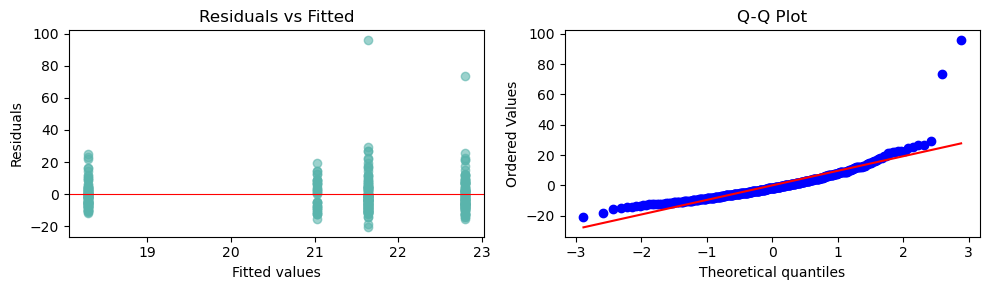

**Observation & Analysis:**

One-way ANOVA detected a significant effect of **Day** on **Amount** (F=3.004, p=0.030501). Group breakdown — Sun (n=114, mean=22.80, total=2599.47, 34.6%); Sat (n=117, mean=21.64, total=2532.04, 33.7%); Fri (n=38, mean=21.03, total=798.95, 10.6%); Thur (n=87, mean=18.28, total=1590.62, 21.1%). The highest average Amount is in the **Sun** group (22.80) and the lowest in the **Thur** group (18.28), a difference of **4.52**. The Sun group contributes **34.6%** of total Amount (2599.47 / 7521.08).

**Managerial Insight:**

Since **Day** significantly influences **Amount**, prioritise the **Sun** category for operational and revenue strategies. The **Thur** group shows the lowest average Amount (18.28); targeted interventions there could close the **4.52-unit gap** with the best-performing group.

<hr>


### CASE 1.3: **Amount** grouped by **PartyGroup**


--- ANOVA Table ---


,sum_sq,df,F,PR(>F)
C(PartyGroup),5766.328971,2.0,27.884708,5.705566e-12
Residual,36498.752384,353.0,NaN,NaN


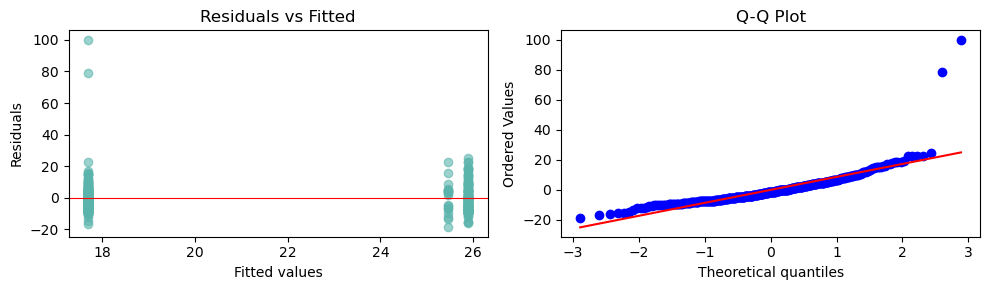

**Observation & Analysis:**

One-way ANOVA detected a significant effect of **PartyGroup** on **Amount** (F=27.885, p=< 0.000001). Group breakdown — Medium [3-4] (n=131, mean=25.90, total=3392.58, 45.1%); Large [5+] (n=19, mean=25.46, total=483.68, 6.4%); Small [1-2] (n=206, mean=17.69, total=3644.82, 48.5%). The highest average Amount is in the **Medium [3-4]** group (25.90) and the lowest in the **Small [1-2]** group (17.69), a difference of **8.20**. The Medium [3-4] group contributes **45.1%** of total Amount (3392.58 / 7521.08).

**Managerial Insight:**

Since **PartyGroup** significantly influences **Amount**, prioritise the **Medium [3-4]** category for operational and revenue strategies. The **Small [1-2]** group shows the lowest average Amount (17.69); targeted interventions there could close the **8.20-unit gap** with the best-performing group.

<hr>


### CASE 2.2: **Amount** grouped by **Smoker** & **Gender**


--- ANOVA Table ---


,sum_sq,df,F,PR(>F)
C(Smoker),509.171082,1.0,4.335055,0.038057
C(Gender),89.081565,1.0,0.758436,0.384412
C(Smoker):C(Gender),291.380537,1.0,2.480798,0.116142
Residual,41343.930088,352.0,NaN,NaN


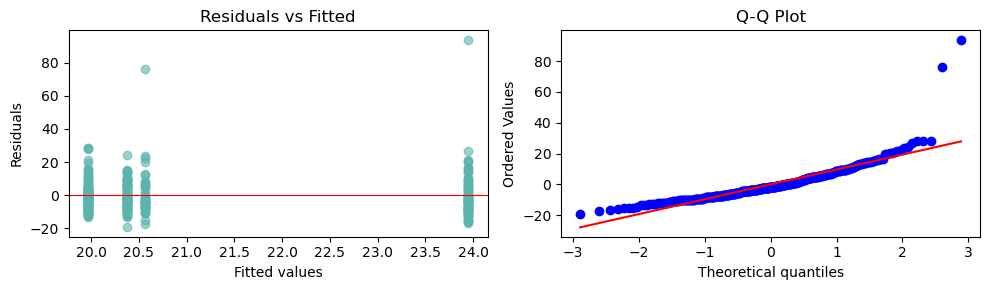

**Observation & Analysis:**

Two-way ANOVA found significant effects on **Amount** — significant term(s): Smoker (F=4.335, p=0.038057). Across **Smoker**: Yes mean=22.68; No mean=20.15. Across **Gender**: Male mean=21.62; Female mean=20.44. These effects indicate that both **Smoker** and **Gender** (and possibly their interaction) shape the **Amount** outcome.

**Managerial Insight:**

The combination of **Smoker** and **Gender** jointly drives **Amount**. Within Smoker, the **Yes** level yields the highest average (22.68); within Gender, **Male** leads (21.62). Prioritise the **Yes × Male** combination for maximum Amount impact, and review the lowest-performing levels of each factor for targeted improvement opportunities.

<hr>


In [2]:
display(Markdown("## Part 1: ANOVA Significant Findings\n---"))

def run_anova_report(case_name, target, factor1, factor2=None):
    if factor2:
        formula = f"{target} ~ C({factor1}) + C({factor2}) + C({factor1}):C({factor2})"
    else:
        formula = f"{target} ~ C({factor1})"
        
    model = ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    p_vals = anova_table['PR(>F)'].dropna()
    
    # Check significance
    if not any(p < 0.05 for p in p_vals):
        return # Skip non-significant
        
    display(Markdown(f"### {case_name}: **{target}** grouped by **{factor1}**" + (f" & **{factor2}**" if factor2 else "")))
    
    # 1. Raw Output
    print("\n--- ANOVA Table ---")
    display(anova_table)
    
    # 2. Visuals (Residuals)
    fig_r, (ax1_r, ax2_r) = plt.subplots(1, 2, figsize=(10, 3))
    ax1_r.scatter(model.fittedvalues, model.resid, alpha=0.6, color="#5ab4ac")
    ax1_r.axhline(0, color="red", linewidth=0.8)
    ax1_r.set_xlabel("Fitted values"); ax1_r.set_ylabel("Residuals")
    ax1_r.set_title(f"Residuals vs Fitted")
    stats.probplot(model.resid, dist="norm", plot=ax2_r)
    ax2_r.set_title(f"Q-Q Plot")
    plt.tight_layout()
    plt.show()

    # 3. Markdown Insight
    if factor2 is None:
        _gstats = df.groupby(factor1)[target].agg(['mean','sum','count']).reset_index()
        _gstats.columns = [factor1,'_mean','_total','_n']
        _gstats = _gstats.sort_values('_mean', ascending=False).reset_index(drop=True)
        _grand = _gstats['_total'].sum()
        _best = _gstats.iloc[0]; _worst = _gstats.iloc[-1]
        _f_val = anova_table.iloc[0]['F']
        _p_val = anova_table.dropna()['PR(>F)'].iloc[0]
        _p_disp = '< 0.000001' if _p_val < 0.000001 else f'{_p_val:.6f}'
        _lines = []
        for _, _r in _gstats.iterrows():
            _pct = 100*_r['_total']/_grand if _grand else 0
            _lines.append(f"{_r[factor1]} (n={int(_r['_n'])}, mean={_r['_mean']:.2f}, total={_r['_total']:.2f}, {_pct:.1f}%)")
        _obs = (
            f"One-way ANOVA detected a significant effect of **{factor1}** on **{target}** "
            f"(F={_f_val:.3f}, p={_p_disp}). "
            f"Group breakdown — {'; '.join(_lines)}. "
            f"The highest average {target} is in the **{_best[factor1]}** group "
            f"({_best['_mean']:.2f}) and the lowest in the **{_worst[factor1]}** group "
            f"({_worst['_mean']:.2f}), a difference of **{_best['_mean']-_worst['_mean']:.2f}**. "
            f"The {_best[factor1]} group contributes "
            f"**{100*_best['_total']/_grand:.1f}%** of total {target} "
            f"({_best['_total']:.2f} / {_grand:.2f})."
        )
        _mgmt = (
            f"Since **{factor1}** significantly influences **{target}**, prioritise the "
            f"**{_best[factor1]}** category for operational and revenue strategies. "
            f"The **{_worst[factor1]}** group shows the lowest average {target} "
            f"({_worst['_mean']:.2f}); targeted interventions there could close "
            f"the **{_best['_mean']-_worst['_mean']:.2f}-unit gap** with the best-performing group."
        )
    else:
        _sig_terms = [(t,r['PR(>F)']) for t,r in anova_table.dropna().iterrows() if r['PR(>F)'] < 0.05]
        _sig_str = '; '.join(
            f"{t.replace('C(','').replace(')','').replace(':',' x ')} "
            f"(F={anova_table.loc[t,'F']:.3f}, p={'< 0.000001' if p2<0.000001 else f'{p2:.6f}'})"
            for t,p2 in _sig_terms
        )
        _g1s = df.groupby(factor1)[target].agg(['mean','sum','count']).reset_index()
        _g1s.columns=[factor1,'_mean','_total','_n']
        _g1s=_g1s.sort_values('_mean',ascending=False).reset_index(drop=True)
        _g2s = df.groupby(factor2)[target].agg(['mean','sum','count']).reset_index()
        _g2s.columns=[factor2,'_mean','_total','_n']
        _g2s=_g2s.sort_values('_mean',ascending=False).reset_index(drop=True)
        _best1=_g1s.iloc[0]; _best2=_g2s.iloc[0]
        _g1_sum='; '.join(f"{r[factor1]} mean={r['_mean']:.2f}" for _,r in _g1s.iterrows())
        _g2_sum='; '.join(f"{r[factor2]} mean={r['_mean']:.2f}" for _,r in _g2s.iterrows())
        _obs=(
            f"Two-way ANOVA found significant effects on **{target}** — "
            f"significant term(s): {_sig_str}. "
            f"Across **{factor1}**: {_g1_sum}. "
            f"Across **{factor2}**: {_g2_sum}. "
            f"These effects indicate that both **{factor1}** and **{factor2}** "
            f"(and possibly their interaction) shape the **{target}** outcome."
        )
        _mgmt=(
            f"The combination of **{factor1}** and **{factor2}** jointly drives **{target}**. "
            f"Within {factor1}, the **{_best1[factor1]}** level yields the highest average "
            f"({_best1['_mean']:.2f}); within {factor2}, **{_best2[factor2]}** leads "
            f"({_best2['_mean']:.2f}). Prioritise the **{_best1[factor1]} × {_best2[factor2]}** "
            f"combination for maximum {target} impact, and review the lowest-performing "
            f"levels of each factor for targeted improvement opportunities."
        )
        
    display(Markdown(f"**Observation & Analysis:**\n\n{_obs}\n\n**Managerial Insight:**\n\n{_mgmt}\n\n<hr>\n"))

# Run the cases
anova_cases = [
    ("CASE 1.1", "Amount", "Day", None),
    ("CASE 1.3", "Amount", "PartyGroup", None),
    ("CASE 2.1", "Amount", "Day", "Time"),
    ("CASE 2.2", "Amount", "Smoker", "Gender")
]

for c in anova_cases:
    run_anova_report(*c)


## Part 2: Welch's T-Test Significant Findings
---

### **Amount** grouped by **Tip** (> 2.88 vs <= 2.88)

--- Welch's T-Test Summary ---
t-statistic: 9.4636
p-value:     < 0.000001
95% CI diff: [7.7744, 11.8591]
Mean > 2.88: 26.0626
Mean <= 2.88: 16.2458



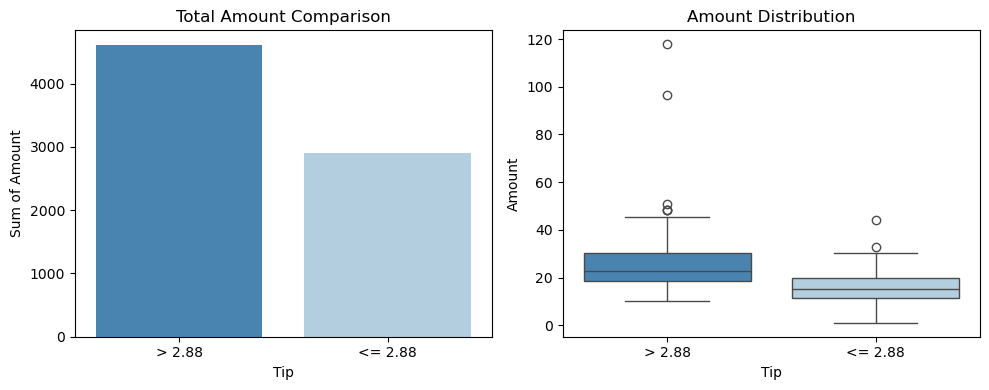

**Observation & Analysis:**

The bar chart comparison of total **Amount** shows that the **> 2.88** group accounts for **4613.08** in total Amount (from 177 records) with an average of **26.06** per record, while the **<= 2.88** group accounts for **2908.00** total (from 179 records) with an average of **16.25** per record. The dataset records **7521.08** in combined Amount (4613.08 / 7521.08, **~61.3%** from > 2.88). After Welch's independent-samples t-test, a statistically significant difference was observed (t=9.4636, p=< 0.000001), indicating that **Tip** exerts a measurable effect on **Amount**.

**Managerial Insight:**

Because the **> 2.88** group produces a higher average Amount (~26.06 vs ~16.25 for <= 2.88), prioritise operational and revenue strategies for the **> 2.88** segment. For the **<= 2.88** group (~16.25 average), consider targeted interventions to close the **9.82-unit gap** with the better-performing segment.

<hr>


### **Amount** grouped by **Partysize** (Large (>2) vs Small (<=2))

--- Welch's T-Test Summary ---
t-statistic: 7.7208
p-value:     < 0.000001
95% CI diff: [6.0727, 10.2241]
Mean Large (>2): 25.8417
Mean Small (<=2): 17.6933



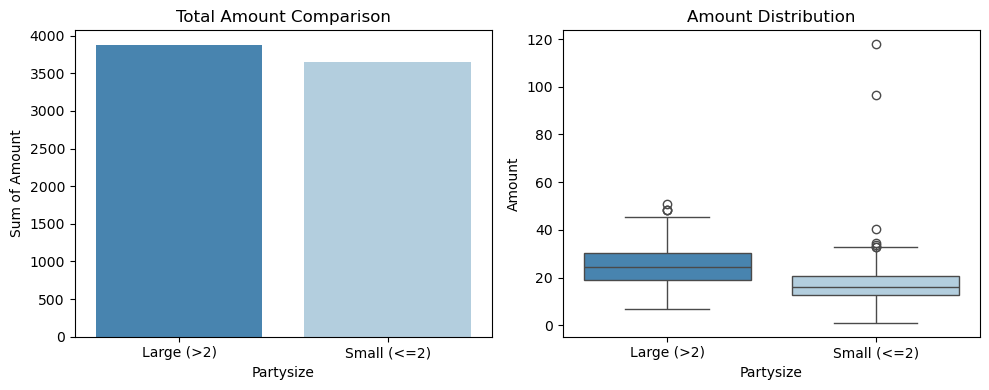

**Observation & Analysis:**

The bar chart comparison of total **Amount** shows that the **Large (>2)** group accounts for **3876.26** in total Amount (from 150 records) with an average of **25.84** per record, while the **Small (<=2)** group accounts for **3644.82** total (from 206 records) with an average of **17.69** per record. The dataset records **7521.08** in combined Amount (3876.26 / 7521.08, **~51.5%** from Large (>2)). After Welch's independent-samples t-test, a statistically significant difference was observed (t=7.7208, p=< 0.000001), indicating that **Partysize** exerts a measurable effect on **Amount**.

**Managerial Insight:**

Because the **Large (>2)** group produces a higher average Amount (~25.84 vs ~17.69 for Small (<=2)), prioritise operational and revenue strategies for the **Large (>2)** segment. For the **Small (<=2)** group (~17.69 average), consider targeted interventions to close the **8.15-unit gap** with the better-performing segment.

<hr>


### **Amount** grouped by **Time** (Dinner vs Lunch)

--- Welch's T-Test Summary ---
t-statistic: 2.0965
p-value:     0.036767
95% CI diff: [0.1414, 4.4327]
Mean Dinner: 21.9746
Mean Lunch: 19.6876



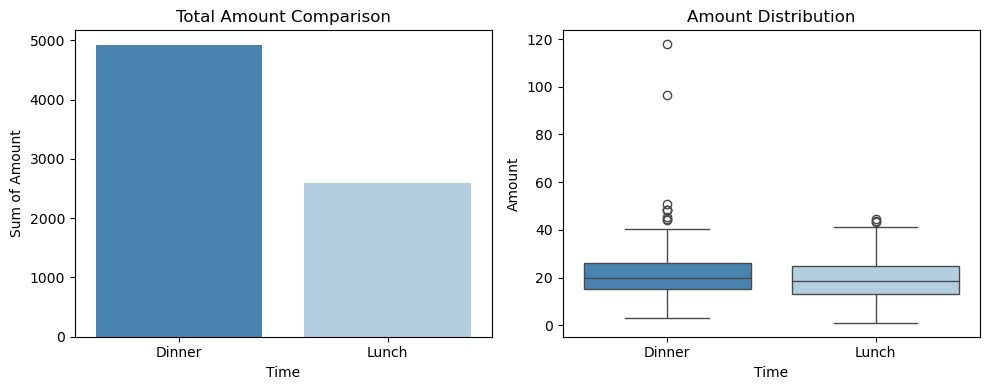

**Observation & Analysis:**

The bar chart comparison of total **Amount** shows that the **Dinner** group accounts for **4922.32** in total Amount (from 224 records) with an average of **21.97** per record, while the **Lunch** group accounts for **2598.76** total (from 132 records) with an average of **19.69** per record. The dataset records **7521.08** in combined Amount (4922.32 / 7521.08, **~65.4%** from Dinner). After Welch's independent-samples t-test, a statistically significant difference was observed (t=2.0965, p=0.036767), indicating that **Time** exerts a measurable effect on **Amount**.

**Managerial Insight:**

Because the **Dinner** group produces a higher average Amount (~21.97 vs ~19.69 for Lunch), prioritise operational and revenue strategies for the **Dinner** segment. For the **Lunch** group (~19.69 average), consider targeted interventions to close the **2.29-unit gap** with the better-performing segment.

<hr>


### **Amount** grouped by **Day** (Weekend vs Weekday)

--- Welch's T-Test Summary ---
t-statistic: 2.8729
p-value:     0.004327
95% CI diff: [0.9767, 5.2188]
Mean Weekend: 22.2143
Mean Weekday: 19.1166



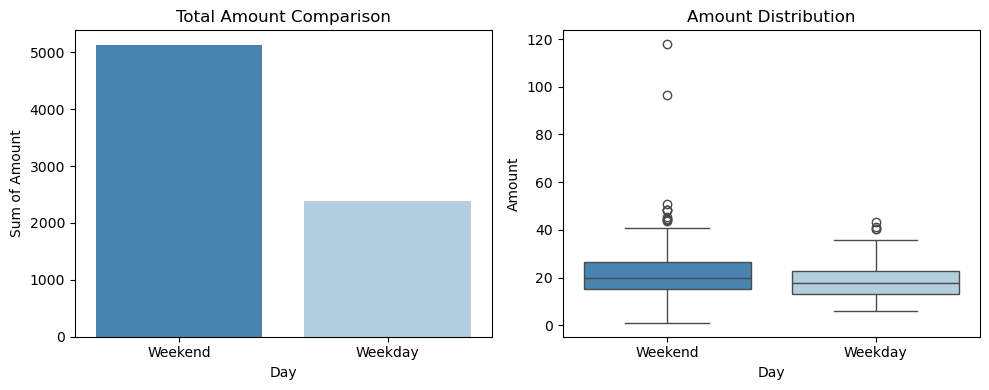

**Observation & Analysis:**

The bar chart comparison of total **Amount** shows that the **Weekend** group accounts for **5131.51** in total Amount (from 231 records) with an average of **22.21** per record, while the **Weekday** group accounts for **2389.57** total (from 125 records) with an average of **19.12** per record. The dataset records **7521.08** in combined Amount (5131.51 / 7521.08, **~68.2%** from Weekend). After Welch's independent-samples t-test, a statistically significant difference was observed (t=2.8729, p=0.004327), indicating that **Day** exerts a measurable effect on **Amount**.

**Managerial Insight:**

Because the **Weekend** group produces a higher average Amount (~22.21 vs ~19.12 for Weekday), prioritise operational and revenue strategies for the **Weekend** segment. For the **Weekday** group (~19.12 average), consider targeted interventions to close the **3.10-unit gap** with the better-performing segment.

<hr>


### **Gender (Male=1)** grouped by **Time** (Dinner vs Lunch)

--- Welch's T-Test Summary ---
t-statistic: 4.4432
p-value:     0.000013
95% CI diff: [0.1324, 0.3432]
Mean Dinner: 0.6696
Mean Lunch: 0.4318



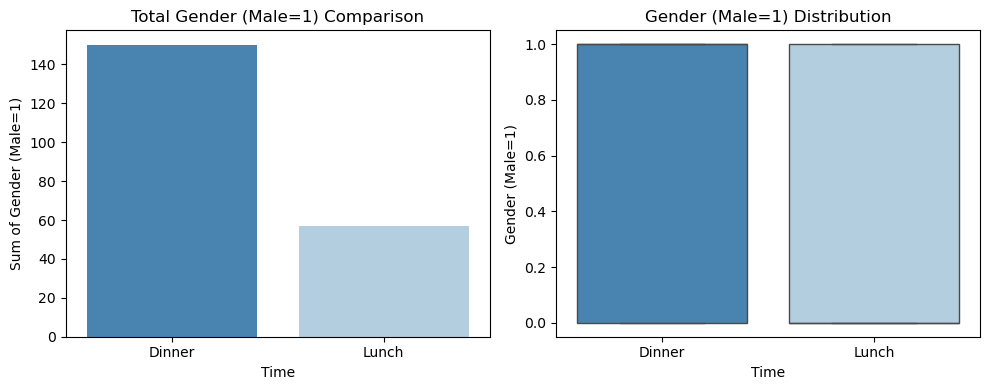

**Observation & Analysis:**

The bar chart comparison of total **Gender (Male=1)** shows that the **Dinner** group accounts for **150.00** in total Gender (Male=1) (from 224 records) with an average of **0.67** per record, while the **Lunch** group accounts for **57.00** total (from 132 records) with an average of **0.43** per record. The dataset records **207.00** in combined Gender (Male=1) (150.00 / 207.00, **~72.5%** from Dinner). After Welch's independent-samples t-test, a statistically significant difference was observed (t=4.4432, p=0.000013), indicating that **Time** exerts a measurable effect on **Gender (Male=1)**.

**Managerial Insight:**

Because the **Dinner** group produces a higher average Gender (Male=1) (~0.67 vs ~0.43 for Lunch), prioritise operational and revenue strategies for the **Dinner** segment. For the **Lunch** group (~0.43 average), consider targeted interventions to close the **0.24-unit gap** with the better-performing segment.

<hr>


### **Time (Dinner=1)** grouped by **Tip** (> 2.88 vs <= 2.88)

--- Welch's T-Test Summary ---
t-statistic: 3.2506
p-value:     0.001263
95% CI diff: [0.0649, 0.2638]
Mean > 2.88: 0.7119
Mean <= 2.88: 0.5475



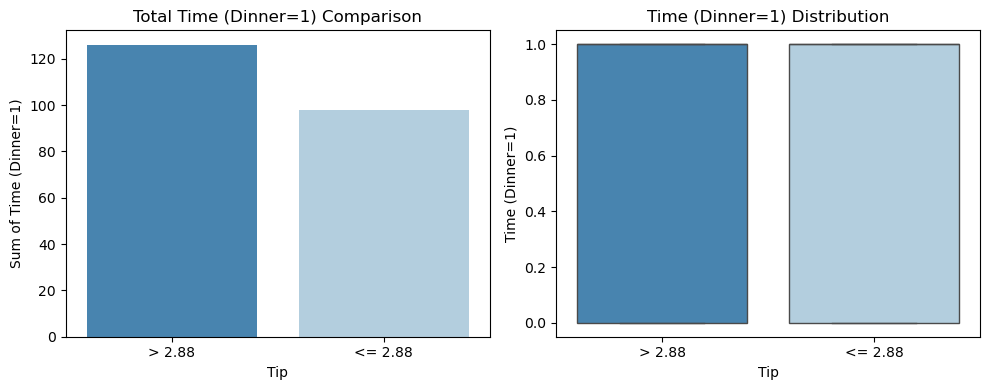

**Observation & Analysis:**

The bar chart comparison of total **Time (Dinner=1)** shows that the **> 2.88** group accounts for **126.00** in total Time (Dinner=1) (from 177 records) with an average of **0.71** per record, while the **<= 2.88** group accounts for **98.00** total (from 179 records) with an average of **0.55** per record. The dataset records **224.00** in combined Time (Dinner=1) (126.00 / 224.00, **~56.2%** from > 2.88). After Welch's independent-samples t-test, a statistically significant difference was observed (t=3.2506, p=0.001263), indicating that **Tip** exerts a measurable effect on **Time (Dinner=1)**.

**Managerial Insight:**

Because the **> 2.88** group produces a higher average Time (Dinner=1) (~0.71 vs ~0.55 for <= 2.88), prioritise operational and revenue strategies for the **> 2.88** segment. For the **<= 2.88** group (~0.55 average), consider targeted interventions to close the **0.16-unit gap** with the better-performing segment.

<hr>


### **Time (Dinner=1)** grouped by **Gender** (Male vs Female)

--- Welch's T-Test Summary ---
t-statistic: 4.4225
p-value:     0.000014
95% CI diff: [0.1265, 0.3295]
Mean Male: 0.7246
Mean Female: 0.4966



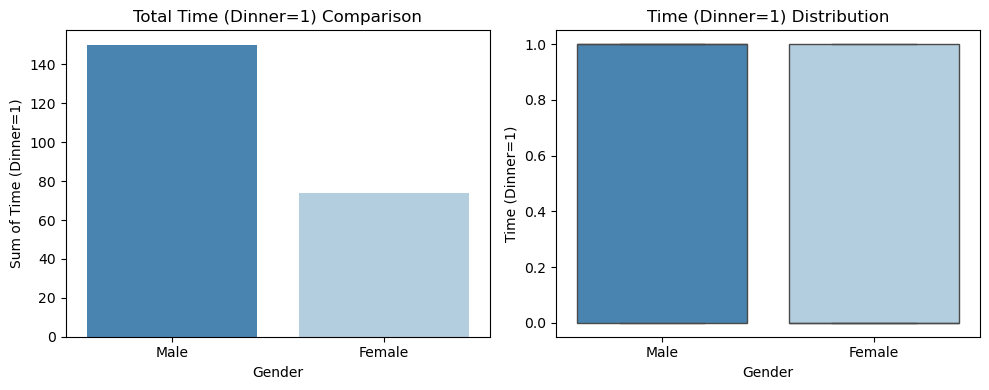

**Observation & Analysis:**

The bar chart comparison of total **Time (Dinner=1)** shows that the **Male** group accounts for **150.00** in total Time (Dinner=1) (from 207 records) with an average of **0.72** per record, while the **Female** group accounts for **74.00** total (from 149 records) with an average of **0.50** per record. The dataset records **224.00** in combined Time (Dinner=1) (150.00 / 224.00, **~67.0%** from Male). After Welch's independent-samples t-test, a statistically significant difference was observed (t=4.4225, p=0.000014), indicating that **Gender** exerts a measurable effect on **Time (Dinner=1)**.

**Managerial Insight:**

Because the **Male** group produces a higher average Time (Dinner=1) (~0.72 vs ~0.50 for Female), prioritise operational and revenue strategies for the **Male** segment. For the **Female** group (~0.50 average), consider targeted interventions to close the **0.23-unit gap** with the better-performing segment.

<hr>


### **Time (Dinner=1)** grouped by **Day** (Weekend vs Weekday)

--- Welch's T-Test Summary ---
t-statistic: 10.2556
p-value:     < 0.000001
95% CI diff: [0.4049, 0.5975]
Mean Weekend: 0.8052
Mean Weekday: 0.3040



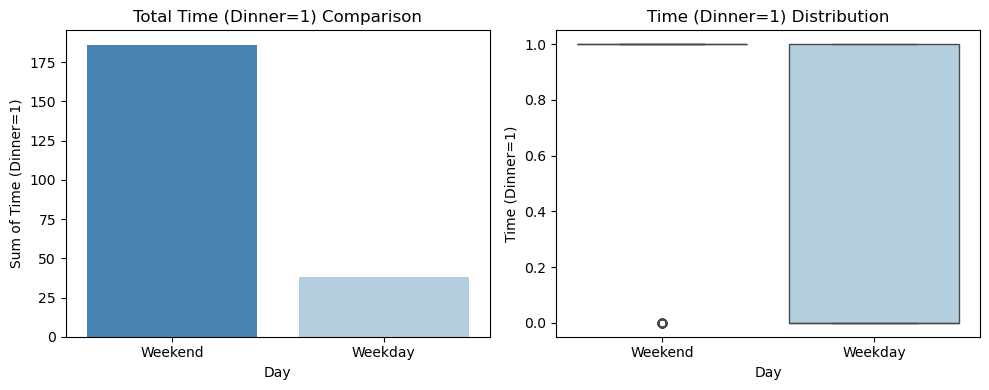

**Observation & Analysis:**

The bar chart comparison of total **Time (Dinner=1)** shows that the **Weekend** group accounts for **186.00** in total Time (Dinner=1) (from 231 records) with an average of **0.81** per record, while the **Weekday** group accounts for **38.00** total (from 125 records) with an average of **0.30** per record. The dataset records **224.00** in combined Time (Dinner=1) (186.00 / 224.00, **~83.0%** from Weekend). After Welch's independent-samples t-test, a statistically significant difference was observed (t=10.2556, p=< 0.000001), indicating that **Day** exerts a measurable effect on **Time (Dinner=1)**.

**Managerial Insight:**

Because the **Weekend** group produces a higher average Time (Dinner=1) (~0.81 vs ~0.30 for Weekday), prioritise operational and revenue strategies for the **Weekend** segment. For the **Weekday** group (~0.30 average), consider targeted interventions to close the **0.50-unit gap** with the better-performing segment.

<hr>


### **Day (Weekend=1)** grouped by **Tip** (> 2.88 vs <= 2.88)

--- Welch's T-Test Summary ---
t-statistic: 2.0387
p-value:     0.042229
95% CI diff: [0.0036, 0.2020]
Mean > 2.88: 0.7006
Mean <= 2.88: 0.5978



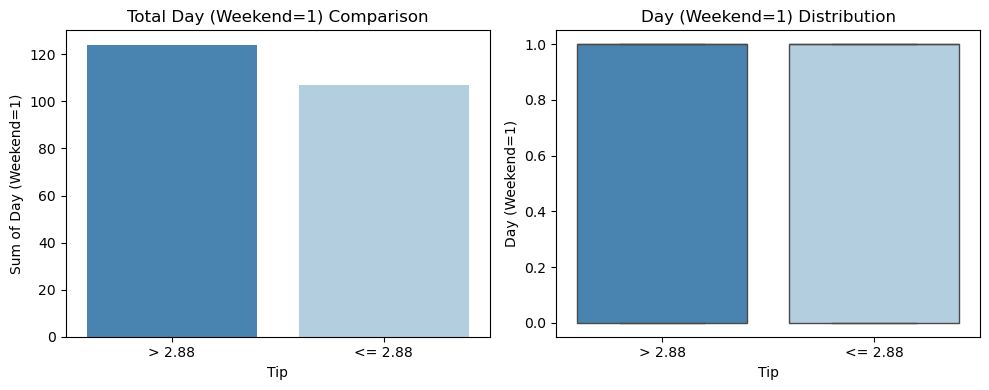

**Observation & Analysis:**

The bar chart comparison of total **Day (Weekend=1)** shows that the **> 2.88** group accounts for **124.00** in total Day (Weekend=1) (from 177 records) with an average of **0.70** per record, while the **<= 2.88** group accounts for **107.00** total (from 179 records) with an average of **0.60** per record. The dataset records **231.00** in combined Day (Weekend=1) (124.00 / 231.00, **~53.7%** from > 2.88). After Welch's independent-samples t-test, a statistically significant difference was observed (t=2.0387, p=0.042229), indicating that **Tip** exerts a measurable effect on **Day (Weekend=1)**.

**Managerial Insight:**

Because the **> 2.88** group produces a higher average Day (Weekend=1) (~0.70 vs ~0.60 for <= 2.88), prioritise operational and revenue strategies for the **> 2.88** segment. For the **<= 2.88** group (~0.60 average), consider targeted interventions to close the **0.10-unit gap** with the better-performing segment.

<hr>


### **Day (Weekend=1)** grouped by **Partysize** (Large (>2) vs Small (<=2))

--- Welch's T-Test Summary ---
t-statistic: 2.4453
p-value:     0.014986
95% CI diff: [0.0240, 0.2218]
Mean Large (>2): 0.7200
Mean Small (<=2): 0.5971



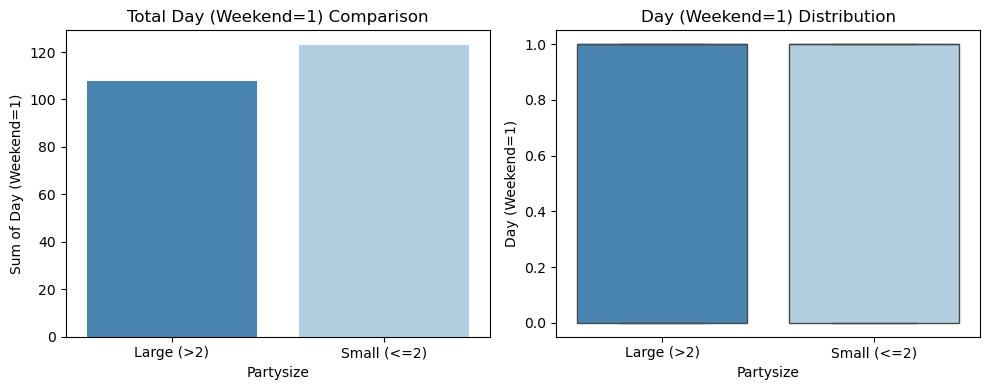

**Observation & Analysis:**

The bar chart comparison of total **Day (Weekend=1)** shows that the **Large (>2)** group accounts for **108.00** in total Day (Weekend=1) (from 150 records) with an average of **0.72** per record, while the **Small (<=2)** group accounts for **123.00** total (from 206 records) with an average of **0.60** per record. The dataset records **231.00** in combined Day (Weekend=1) (108.00 / 231.00, **~46.8%** from Large (>2)). After Welch's independent-samples t-test, a statistically significant difference was observed (t=2.4453, p=0.014986), indicating that **Partysize** exerts a measurable effect on **Day (Weekend=1)**.

**Managerial Insight:**

Because the **Large (>2)** group produces a higher average Day (Weekend=1) (~0.72 vs ~0.60 for Small (<=2)), prioritise operational and revenue strategies for the **Large (>2)** segment. For the **Small (<=2)** group (~0.60 average), consider targeted interventions to close the **0.12-unit gap** with the better-performing segment.

<hr>


### **Day (Weekend=1)** grouped by **Time** (Dinner vs Lunch)

--- Welch's T-Test Summary ---
t-statistic: 10.1033
p-value:     < 0.000001
95% CI diff: [0.3940, 0.5849]
Mean Dinner: 0.8304
Mean Lunch: 0.3409



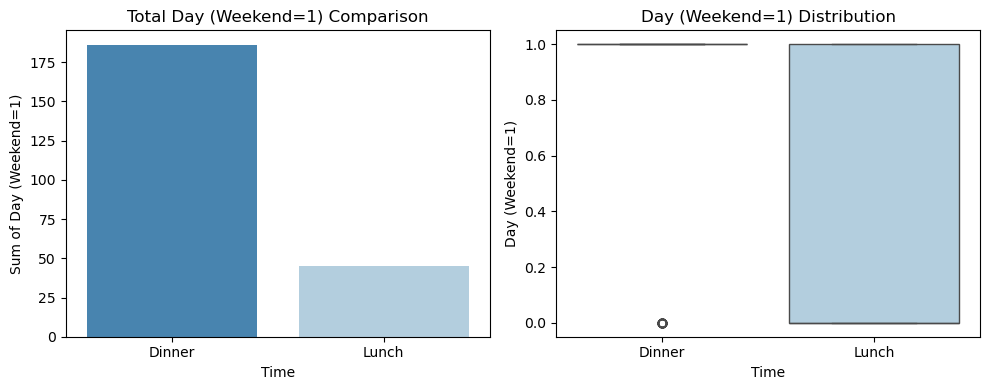

**Observation & Analysis:**

The bar chart comparison of total **Day (Weekend=1)** shows that the **Dinner** group accounts for **186.00** in total Day (Weekend=1) (from 224 records) with an average of **0.83** per record, while the **Lunch** group accounts for **45.00** total (from 132 records) with an average of **0.34** per record. The dataset records **231.00** in combined Day (Weekend=1) (186.00 / 231.00, **~80.5%** from Dinner). After Welch's independent-samples t-test, a statistically significant difference was observed (t=10.1033, p=< 0.000001), indicating that **Time** exerts a measurable effect on **Day (Weekend=1)**.

**Managerial Insight:**

Because the **Dinner** group produces a higher average Day (Weekend=1) (~0.83 vs ~0.34 for Lunch), prioritise operational and revenue strategies for the **Dinner** segment. For the **Lunch** group (~0.34 average), consider targeted interventions to close the **0.49-unit gap** with the better-performing segment.

<hr>


In [3]:
display(Markdown("## Part 2: Welch's T-Test Significant Findings\n---"))

def run_ttest_report(target_col, feature_name, g1, g2, label1, label2):
    g1 = g1.dropna(); g2 = g2.dropna()
    if len(g1) == 0 or len(g2) == 0: return
    
    mean1, mean2 = g1.mean(), g2.mean()
    n1, n2 = len(g1), len(g2)
    mean_diff = mean1 - mean2
    t_stat, p_ttest = stats.ttest_ind(g1, g2, equal_var=False)
    
    if p_ttest >= 0.05: return # Skip non-significant
    
    se1_sq = g1.var(ddof=1) / n1
    se2_sq = g2.var(ddof=1) / n2
    se_diff = np.sqrt(se1_sq + se2_sq)
    df_w = (se1_sq + se2_sq)**2 / (se1_sq**2/(n1-1) + se2_sq**2/(n2-1))
    t_crit = stats.t.ppf(0.975, df=df_w)
    ci_lo = mean_diff - t_crit * se_diff
    ci_hi = mean_diff + t_crit * se_diff
    
    _higher = label1 if mean1 >= mean2 else label2
    _lower  = label2 if mean1 >= mean2 else label1
    _p_disp = '< 0.000001' if p_ttest < 0.000001 else f'{p_ttest:.6f}'
    
    display(Markdown(f"### **{target_col}** grouped by **{feature_name}** ({_higher} vs {_lower})"))
    
    # 1. Raw Output
    print(f"--- Welch's T-Test Summary ---")
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value:     {_p_disp}")
    print(f"95% CI diff: [{ci_lo:.4f}, {ci_hi:.4f}]")
    print(f"Mean {_higher}: {max(mean1, mean2):.4f}")
    print(f"Mean {_lower}: {min(mean1, mean2):.4f}")
    print("")
    
    # 2. Visuals (Bar and Box Plot)
    fig_t, (ax1_t, ax2_t) = plt.subplots(1, 2, figsize=(10, 4))
    
    # Construct dataframe for seaborn
    temp_df = pd.DataFrame({
        target_col: list(g1) + list(g2),
        feature_name: [label1]*n1 + [label2]*n2
    })
    
    sns.barplot(data=temp_df, x=feature_name, y=target_col, ax=ax1_t, palette='Blues_r', errorbar=None)
    ax1_t.set_title(f"Total {target_col} Comparison")
    # Change to sum estimator for bar plot
    sns.barplot(data=temp_df, x=feature_name, y=target_col, ax=ax1_t, palette='Blues_r', estimator=np.sum, errorbar=None)
    ax1_t.set_ylabel(f"Sum of {target_col}")

    sns.boxplot(data=temp_df, x=feature_name, y=target_col, ax=ax2_t, palette='Blues_r')
    ax2_t.set_title(f"{target_col} Distribution")
    
    plt.tight_layout()
    plt.show()
    
    # 3. Markdown Insight
    _total1=g1.sum(); _total2=g2.sum(); _grand_tot=_total1+_total2
    _pct1=100*_total1/_grand_tot if _grand_tot else 0
    _h_mean=max(mean1,mean2); _l_mean=min(mean1,mean2)
    _h_total=_total1 if mean1>=mean2 else _total2
    _l_total=_total2 if mean1>=mean2 else _total1
    _h_n=n1 if mean1>=mean2 else n2
    _l_n=n2 if mean1>=mean2 else n1
    _h_pct=_pct1 if mean1>=mean2 else 100-_pct1
    
    _obs=(
        f"The bar chart comparison of total **{target_col}** shows that the "
        f"**{_higher}** group accounts for **{_h_total:.2f}** in total {target_col} "
        f"(from {_h_n} records) with an average of **{_h_mean:.2f}** per record, "
        f"while the **{_lower}** group accounts for **{_l_total:.2f}** total "
        f"(from {_l_n} records) with an average of **{_l_mean:.2f}** per record. "
        f"The dataset records **{_grand_tot:.2f}** in combined {target_col} "
        f"({_h_total:.2f} / {_grand_tot:.2f}, **~{_h_pct:.1f}%** from {_higher}). "
        f"After Welch's independent-samples t-test, a statistically significant "
        f"difference was observed (t={t_stat:.4f}, p={_p_disp}), indicating that "
        f"**{feature_name}** exerts a measurable effect on **{target_col}**."
    )
    _mgmt=(
        f"Because the **{_higher}** group produces a higher average {target_col} "
        f"(~{_h_mean:.2f} vs ~{_l_mean:.2f} for {_lower}), prioritise operational "
        f"and revenue strategies for the **{_higher}** segment. For the **{_lower}** "
        f"group (~{_l_mean:.2f} average), consider targeted interventions to close "
        f"the **{_h_mean-_l_mean:.2f}-unit gap** with the better-performing segment."
    )
    
    display(Markdown(f"**Observation & Analysis:**\n\n{_obs}\n\n**Managerial Insight:**\n\n{_mgmt}\n\n<hr>\n"))

# Target / Feature combinations
median_tip=df['Tip'].median()
features = {
    'Tip':      (df['Tip']>median_tip,           df['Tip']<=median_tip,            f'> {median_tip:.2f}', f'<= {median_tip:.2f}'),
    'Partysize':(df['Partysize']>2,               df['Partysize']<=2,               'Large (>2)','Small (<=2)'),
    'Gender':   (df['Gender']=='Male',            df['Gender']=='Female',           'Male','Female'),
    'Smoker':   (df['Smoker']=='Yes',             df['Smoker']=='No',               'Smoker','Non-Smoker'),
    'Time':     (df['Time']=='Dinner',            df['Time']=='Lunch',              'Dinner','Lunch'),
    'Day':      (df['Day'].isin(['Sat','Sun']),   df['Day'].isin(['Thur','Fri']),   'Weekend','Weekday'),
}
targets = {
    'Amount':df['Amount'],
    'Gender (Male=1)':df['Gender_Num'],
    'Smoker (Yes=1)':df['Smoker_Num'],
    'Time (Dinner=1)':df['Time_Num'],
    'Day (Weekend=1)':df['Day_Num']
}

for tn, td in targets.items():
    for fn, (c1,c2,l1,l2) in features.items():
        if tn.split(' ')[0]==fn: continue
        run_ttest_report(tn, fn, td[c1], td[c2], l1, l2)
